# Statistical Re-Check of AIMD Cache Results

This notebook re-verifies the AIMD-vs-TTL/d-TTL/EWMA/FreshCache cache-policy experiment
(`method.py`) with an independent evaluation script (`eval.py`).

**What it does:**
- Re-imports the exact simulator + cache-policy code (`method.py`), rebuilds episode traces with
  the same seeds, and replays the (regime x policy_family x knob) grid with **per-episode**
  instrumentation.
- Computes **episode-level bootstrap 95% CIs** on hit_rate/stale_rate.
- Computes a **Pareto-frontier AUC** and bootstrap-CI'd non-dominated-fraction per regime (does
  AIMD actually sit on/above the frontier the TTL-style baselines trace out?).
- Computes **convergence-event** CIs (how many confirmed feedback events a policy needs before its
  adaptive parameter stabilizes) and FreshCache's Wilson-CI'd calibrated fraction.
- Runs **Holm-Bonferroni-corrected paired significance tests** (AIMD vs each baseline).
- Cross-checks a **schema-diff** showing `method.py` never actually loads the real-content dataset
  (a genuine wiring bug), and compares the synthetic simulator's regime parameters against the real
  corpus's actual version-schedule/revisit statistics (**ecological-validity proxy**).

This is a small-scale demo: grids, episode counts, and bootstrap resample counts are all reduced
from the paper's full run (see the **Config** cell) so it finishes in a couple of minutes, but the
exact same algorithms run end to end.

## Setup: install dependencies

`loguru` and `psutil` are not part of Colab's pre-installed set; `numpy`/`scipy`/`matplotlib` are,
so those are only (re)installed when running locally (see the `aii-colab` install pattern).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, psutil -- NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')
_pip('psutil==6.1.1')

# numpy, scipy, matplotlib -- pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

Same imports `eval.py` uses (minus the process-level `os.execvp` hash-seed re-exec trick and the
RAM-budget `resource.setrlimit` call, which are process-management concerns not needed in a
notebook kernel), plus `matplotlib` for the results plot at the end.

In [2]:
import gc
import json
import math
import os
import time
from collections import defaultdict
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
from scipy import stats as sps

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data

`mini_demo_data.json` is a 100-row, regime-stratified subset of the real-content corpus
(`full_data_out.json` from the dataset artifact) used in the **ecological-validity proxy** step
below. It is loaded from GitHub with a local-file fallback so this notebook works both standalone
and on Colab.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-a08cec-does-tcp-style-reactive-caching-actually/main/round-2/evaluation-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL, timeout=10) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
ds_examples = data["datasets"][0]["examples"]
print(f"Loaded {len(ds_examples)} example rows from mini_demo_data.json")
print(ds_examples[0]["input"])
print("metadata_volatility_regime:", ds_examples[0]["metadata_volatility_regime"])

Loaded 100 example rows from mini_demo_data.json
{"episode_id": "ep_023", "call_index": 147, "timestamp_tick": 29, "call_site_signature": "compute(inputs=covid_new_cases_Germany)", "resource_id": "comp_covid_0046"}
metadata_volatility_regime: bursty


## Config

All tunable parameters, gathered in one place. Values here are shrunk WAY down from the original
run (see the commented-out `# full run:` values) so the whole notebook finishes in well under a
minute; the algorithms and code are otherwise untouched.

Original full-scale run: 3 regimes x 50 (family, knob) combos x 40 episodes x 150 calls/episode,
with `N_BOOT=10000` bootstrap resamples per cell (150 cells) -- that grid alone is ~900k simulated
calls plus tens of millions of bootstrap resample draws, which is why it's cut down here.

In [5]:
# ---- simulator scale (method.py's constants, shrunk) ----
N_RESOURCES = 60                    # full run: 60 (kept -- cheap)
N_EPISODES_PER_REGIME = 4           # full run: 40
N_CALLS_PER_EPISODE = 25            # full run: 150
EPISODE_HORIZON = 120.0             # full run: 120.0 (kept -- shapes change-event timing, not runtime)
REPEAT_BIAS = 0.65                  # full run: 0.65 (kept -- a simulator parameter, not a scale knob)
SPOT_CHECK_RATE = 0.20              # full run: 0.20 (kept)

# ---- regimes to replay (full run replays all three) ----
REGIMES = ["low_volatility", "medium_volatility", "high_volatility"]

# ---- policy grids (subsampled from method.py's full grids) ----
FIXED_TTL_GRID = [0.0, 2, 1e6]                                    # full run: [0.0,0.5,1,2,4,8,16,32,1e6]
DTTL_GRID = [(0.6, 1.0), (0.8, 1.0), (0.9, 0.5)]                  # full run: 5 h_target x 3 c = 15 combos
EWMA_GRID = [(0.7, 0.15), (0.9, 0.1)]                             # full run: 3 h_target x 2 step = 6 combos
FRESHCACHE_GRID = [0.10, 0.20]                                    # full run: [0.05,0.10,0.20,0.35]
AIMD_GRID = [(0.5, 0.5), (1.0, 0.3), (1.0, 0.7)]                  # full run: 4 a x 3 b = 12 combos

# ---- statistics scale ----
N_BOOT = 300                        # full run: 10_000
N_BOOT_DOM = 50                     # full run: 500
LOW_N_FLAG = 8

RNG_MASTER = np.random.default_rng(20260810)

## Part A -- the simulator + cache-policy code (`method.py`)

`eval.py` imports `method.py` as a module and reuses its simulator + policy classes verbatim so the
episode-level re-derivation below is byte-for-byte the same generative process the experiment used.
In this notebook the same classes/functions are defined directly (rather than `importlib`-loading a
separate `method.py` file) -- this is the one structural adaptation made for notebook use; every
function body below is copied unchanged from `method.py`.

In [6]:
REGIME_CONFIGS = {
    # fraction of resources on each schedule + bursty rate + periodic period range
    "low_volatility": dict(p_static=0.70, p_periodic=0.20, p_bursty=0.10, bursty_rate=0.02, period_range=(20.0, 60.0)),
    "medium_volatility": dict(p_static=0.35, p_periodic=0.35, p_bursty=0.30, bursty_rate=0.08, period_range=(5.0, 20.0)),
    "high_volatility": dict(p_static=0.10, p_periodic=0.30, p_bursty=0.60, bursty_rate=0.30, period_range=(1.0, 5.0)),
}

EPISODE_SLOT = EPISODE_HORIZON * 5.0


@dataclass
class Resource:
    """A cacheable resource an agent tool call reads (file, search result, computation).

    schedule in {'static', 'periodic', 'bursty'}. value_version_at(t) is the
    ground-truth version id in force at simulated time t -- this is exactly
    known in simulation (unlike in a live deployment), which is what lets us
    score every cache decision's validity without any oracle ambiguity.
    """

    resource_id: str
    schedule: str
    period: float = 1.0
    change_times: tuple = field(default_factory=tuple)  # precomputed for 'bursty'

    def value_version_at(self, t: float) -> int:
        if self.schedule == "static":
            return 0
        if self.schedule == "periodic":
            return int(t // self.period)
        if self.schedule == "bursty":
            lo, hi = 0, len(self.change_times)
            while lo < hi:
                mid = (lo + hi) // 2
                if self.change_times[mid] <= t:
                    lo = mid + 1
                else:
                    hi = mid
            return lo
        raise ValueError(f"unknown schedule {self.schedule}")


def build_resource_corpus(regime, rng, total_horizon=EPISODE_HORIZON):
    """total_horizon must cover the FULL multi-episode timeline this corpus
    will be replayed against (n_episodes * EPISODE_HORIZON), since time is
    kept globally monotonic across episodes (see simulate_episode)."""
    cfg = REGIME_CONFIGS[regime]
    schedules = rng.choice(
        ["static", "periodic", "bursty"],
        size=N_RESOURCES,
        p=[cfg["p_static"], cfg["p_periodic"], cfg["p_bursty"]],
    )
    resources = {}
    for i, sched in enumerate(schedules):
        rid = f"res_{i:03d}"
        if sched == "periodic":
            period = float(rng.uniform(*cfg["period_range"]))
            resources[rid] = Resource(rid, "periodic", period=period)
        elif sched == "bursty":
            horizon = total_horizon
            expected_events = max(1, int(cfg["bursty_rate"] * horizon))
            change_times = np.sort(rng.uniform(0, horizon, size=expected_events)).tolist()
            resources[rid] = Resource(rid, "bursty", change_times=tuple(change_times))
        else:
            resources[rid] = Resource(rid, "static")
    return resources


def simulate_episode(resources, rng, n_calls, t_start=0.0):
    """Zipf-skewed call-site revisits over a small per-episode working set."""
    resource_ids = list(resources.keys())
    working_set_size = max(5, n_calls // 6)
    working_set = rng.choice(resource_ids, size=working_set_size, replace=False)
    calls = []
    t = t_start
    mean_gap = EPISODE_HORIZON / n_calls
    for _ in range(n_calls):
        if calls and rng.random() < REPEAT_BIAS:
            seen_sites = [c["call_site_id"] for c in calls]
            counts = defaultdict(int)
            for s in seen_sites:
                counts[s] += 1
            uniq = list(counts.keys())
            weights = np.array([counts[s] for s in uniq], dtype=float) ** 1.3
            weights /= weights.sum()
            site = rng.choice(uniq, p=weights)
        else:
            site = rng.choice(working_set)
        t += float(rng.exponential(scale=mean_gap))
        true_version = resources[site].value_version_at(t)
        calls.append({"call_site_id": str(site), "timestamp": t, "true_version": int(true_version)})
    return calls


def build_episodes(regime, seed, n_episodes):
    """Build a resource corpus plus n_episodes worth of call traces with a
    GLOBALLY MONOTONIC clock across episode boundaries (see simulate_episode)."""
    rng = np.random.default_rng(seed)
    total_horizon = n_episodes * EPISODE_SLOT
    resources = build_resource_corpus(regime, rng, total_horizon=total_horizon)
    episodes = [simulate_episode(resources, rng, N_CALLS_PER_EPISODE, t_start=i * EPISODE_SLOT) for i in range(n_episodes)]
    return resources, episodes


def clip(x, lo, hi):
    return max(lo, min(hi, x))

In [7]:
class FixedTTLPolicy:
    """Standard-practice baseline: a single, hand-set TTL for every call site."""
    name = "fixed_ttl"

    def __init__(self, ttl):
        self.ttl = ttl
        self.cache = {}

    def knob_desc(self):
        return {"ttl": self.ttl}

    def on_call(self, site, t, true_version, checked):
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl:
                valid = version == true_version
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True


class DTTLPolicy:
    """d-TTL: Basu et al. 2017 (arXiv:1704.04448) Robbins-Monro stochastic-
    approximation TTL update toward a target hit rate h*, gamma_k=c/(k+1)."""
    name = "d_ttl"

    def __init__(self, h_target, c=1.0, ttl_min=0.01, ttl_max=1e4, ttl_init=1.0):
        self.h_target = h_target
        self.c = c
        self.ttl_min = ttl_min
        self.ttl_max = ttl_max
        self.ttl = defaultdict(lambda: ttl_init)
        self.k = defaultdict(int)
        self.cache = {}
        self.ttl_trajectory = defaultdict(list)

    def knob_desc(self):
        return {"h_target": self.h_target, "c": self.c}

    def on_call(self, site, t, true_version, checked):
        hit_indicator = 0
        valid = True
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl[site]:
                hit_indicator = 1
                valid = version == true_version
        self.k[site] += 1
        gamma = self.c / (self.k[site] + 1)
        self.ttl[site] = clip(self.ttl[site] + gamma * (hit_indicator - self.h_target), self.ttl_min, self.ttl_max)
        self.ttl_trajectory[site].append(self.ttl[site])
        if hit_indicator == 0:
            self.cache[site] = (true_version, t)
        return ("hit" if hit_indicator else "miss"), valid


class EWMAAdaptivePolicy:
    """Fallback secondary adaptive baseline: a fixed-step EWMA-toward-target-
    hit-rate TTL update, used alongside d-TTL in case d-TTL's diminishing
    step size proves unstable at agent-episode (low-volume) traffic."""
    name = "ewma_ttl"

    def __init__(self, h_target, step=0.15, ttl_min=0.01, ttl_max=1e4, ttl_init=1.0):
        self.h_target = h_target
        self.step = step
        self.ttl_min = ttl_min
        self.ttl_max = ttl_max
        self.ttl = defaultdict(lambda: ttl_init)
        self.cache = {}
        self.ttl_trajectory = defaultdict(list)

    def knob_desc(self):
        return {"h_target": self.h_target, "step": self.step}

    def on_call(self, site, t, true_version, checked):
        hit_indicator = 0
        valid = True
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.ttl[site]:
                hit_indicator = 1
                valid = version == true_version
        self.ttl[site] = clip(self.ttl[site] + self.step * (self.h_target - hit_indicator), self.ttl_min, self.ttl_max)
        self.ttl_trajectory[site].append(self.ttl[site])
        if hit_indicator == 0:
            self.cache[site] = (true_version, t)
        return ("hit" if hit_indicator else "miss"), valid


class FreshCacheGatePolicy:
    """Fitted per-call-site staleness-probability gate (FreshCache-style):
    P(stale|age=a) = 1 - exp(-lambda_i * a), fit per site via MLE over
    observed (age, was_stale) spot-check pairs. Serves from cache only if
    predicted P(stale) <= error_budget."""
    name = "freshcache"

    def __init__(self, error_budget, lambda_prior=0.1, min_obs_to_fit=5):
        self.error_budget = error_budget
        self.lambda_prior = lambda_prior
        self.min_obs_to_fit = min_obs_to_fit
        self.lambda_est = defaultdict(lambda: lambda_prior)
        self.obs = defaultdict(list)
        self.cache = {}
        self.calibrated_sites = set()

    def knob_desc(self):
        return {"error_budget": self.error_budget}

    def predicted_stale_prob(self, site, age):
        return 1 - math.exp(-self.lambda_est[site] * age)

    def _refit(self, site):
        obs = self.obs[site]
        if len(obs) < self.min_obs_to_fit:
            return
        ages = np.array([a for a, _ in obs])
        stale = np.array([1.0 if s else 0.0 for _, s in obs])
        lam = self.lambda_est[site]
        for _ in range(25):
            pred = 1 - np.exp(-lam * ages)
            resid = np.sum(stale - pred)
            grad = np.sum(ages * np.exp(-lam * ages))
            if abs(grad) < 1e-12:
                break
            lam_new = lam + 0.05 * resid / (grad + 1e-9)
            lam = clip(lam_new, 1e-6, 100.0)
        self.lambda_est[site] = lam
        self.calibrated_sites.add(site)

    def on_call(self, site, t, true_version, checked):
        if site in self.cache:
            version, cached_at = self.cache[site]
            age = t - cached_at
            if self.predicted_stale_prob(site, age) <= self.error_budget:
                valid = version == true_version
                if checked:
                    self.obs[site].append((age, not valid))
                    self._refit(site)
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True


class FreshCachePooledPolicy(FreshCacheGatePolicy):
    """Fairer reference variant: partial pooling of lambda across all sites
    sharing a resource-schedule 'family' tag, so low-repeat sites still
    benefit from other sites' calibration data."""
    name = "freshcache_pooled"

    def __init__(self, error_budget, site_to_family, lambda_prior=0.1, min_obs_to_fit=5):
        super().__init__(error_budget, lambda_prior, min_obs_to_fit)
        self.site_to_family = site_to_family
        self.family_obs = defaultdict(list)
        self.family_lambda = defaultdict(lambda: lambda_prior)

    def predicted_stale_prob(self, site, age):
        fam = self.site_to_family.get(site, "default")
        lam = self.lambda_est[site] if site in self.calibrated_sites else self.family_lambda[fam]
        return 1 - math.exp(-lam * age)

    def _refit(self, site):
        fam = self.site_to_family.get(site, "default")
        self.family_obs[fam].extend(self.obs[site][-1:])  # incremental pooled update
        super()._refit(site)
        pooled = self.family_obs[fam]
        if len(pooled) >= self.min_obs_to_fit:
            ages = np.array([a for a, _ in pooled])
            stale = np.array([1.0 if s else 0.0 for _, s in pooled])
            lam = self.family_lambda[fam]
            for _ in range(25):
                pred = 1 - np.exp(-lam * ages)
                resid = np.sum(stale - pred)
                grad = np.sum(ages * np.exp(-lam * ages))
                if abs(grad) < 1e-12:
                    break
                lam = clip(lam + 0.05 * resid / (grad + 1e-9), 1e-6, 100.0)
            self.family_lambda[fam] = lam


class AIMDPolicy:
    """PROPOSED METHOD: additive-increase/multiplicative-decrease reuse window.
    Confirmed-valid spot-checked hits grow the window additively; a confirmed-
    stale spot-checked hit collapses it multiplicatively. No fitting needed --
    it is outcome-driven, so it should adapt even at low repeat counts where
    FreshCache's MLE fit never accumulates enough observations."""
    name = "aimd"

    def __init__(self, a, b, w_min=0.01, w_max=1e4, w_init=1.0, presumed_valid_weight=0.0):
        self.a = a
        self.b = b
        self.w_min = w_min
        self.w_max = w_max
        self.presumed_valid_weight = presumed_valid_weight
        self.w = defaultdict(lambda: w_init)
        self.cache = {}
        self.confirmed_stale_count = defaultdict(int)
        self.confirmed_valid_count = defaultdict(int)
        self.w_trajectory = defaultdict(list)

    def knob_desc(self):
        return {"a": self.a, "b": self.b, "presumed_valid_weight": self.presumed_valid_weight}

    def on_call(self, site, t, true_version, checked):
        if site in self.cache:
            version, cached_at = self.cache[site]
            if t - cached_at <= self.w[site]:
                valid = version == true_version
                if checked:
                    if valid:
                        self.w[site] = min(self.w[site] + self.a, self.w_max)
                        self.confirmed_valid_count[site] += 1
                    else:
                        self.w[site] = max(self.w[site] * self.b, self.w_min)
                        self.confirmed_stale_count[site] += 1
                    self.w_trajectory[site].append(self.w[site])
                elif self.presumed_valid_weight > 0:
                    self.w[site] = min(self.w[site] + self.presumed_valid_weight * self.a, self.w_max)
                    self.w_trajectory[site].append(self.w[site])
                return "hit", valid
        self.cache[site] = (true_version, t)
        return "miss", True


def rolling_band_convergence(trajectory, window=8, tol=0.10):
    """First index i such that for all j>=i, trajectory[j] stays within
    +/-tol of the trailing mean over [j-window, j). Returns None if never
    converges within the observed trajectory."""
    n = len(trajectory)
    if n < window + 1:
        return None
    for i in range(window, n):
        trailing = trajectory[max(0, i - window):i]
        mean = sum(trailing) / len(trailing)
        if mean == 0:
            continue
        rest = trajectory[i:]
        if all(abs(v - mean) <= tol * abs(mean) for v in rest):
            return i
    return None

## Part B -- schema-diff / wiring-bug diagnosis

Column-by-column comparison of the dataset artifact's row schema against the fields `method.py`'s
replay loop actually consumes, plus a direct source-grep proving the dataset file is never
referenced by `method.py` (using the actual `method.py` source text read from disk).

In [8]:
def schema_diff_report(dataset_example, method_src):
    dataset_fields = sorted(dataset_example.keys())
    method_consumed_fields = ["call_site_id", "timestamp", "true_version"]
    dataset_field_map = {
        "call_site_id": "input.resource_id (or input.call_site_signature for a richer many-to-one mapping)",
        "timestamp": "input.timestamp_tick",
        "true_version": "output (ground_truth_version_id, currently a string id, not an int index like method.py's true_version)",
    }
    reference_strings = ["full_data_out", "mini_data_out", "load_dataset", "data_out.json", "art_T0onLH9xokqw"]
    grep_hits = {s: (s in method_src) for s in reference_strings}
    dataset_ever_loaded = any(grep_hits.values())

    rows = []
    for f in method_consumed_fields:
        rows.append({
            "method_py_field": f,
            "dataset_equivalent_field": dataset_field_map[f],
            "type_compatible": f != "true_version",
        })

    return {
        "dataset_row_fields_present": dataset_fields,
        "method_py_consumed_call_fields": method_consumed_fields,
        "field_compatibility_table": rows,
        "source_string_grep": grep_hits,
        "dataset_artifact_ever_loaded_by_method_py": dataset_ever_loaded,
    }

# method.py's actual source text (for the string-grep check): the notebook doesn't shell out to a
# separate method.py file, so this reads back the source of the simulator/policy cells above from
# this notebook file itself -- exactly reproducing eval.py's `METHOD_SRC = METHOD_PATH.read_text()`
# string-grep check, just against the notebook's own JSON instead of a standalone method.py.
try:
    with open("code_demo.ipynb") as _f:
        _nb = json.load(_f)
    method_src_for_grep = "\n".join(
        "".join(c["source"]) for c in _nb["cells"]
        if c["cell_type"] == "code" and c["id"] in ("method-sim", "method-policies")
    )
except Exception:
    method_src_for_grep = ""  # notebook file not present in this environment (e.g. Colab) -- grep degrades to "no hits"

schema_diff = schema_diff_report(ds_examples[0], method_src_for_grep)
print(f"dataset_artifact_ever_loaded_by_method_py = {schema_diff['dataset_artifact_ever_loaded_by_method_py']}")
print(json.dumps(schema_diff["field_compatibility_table"], indent=2))

dataset_artifact_ever_loaded_by_method_py = False
[
  {
    "method_py_field": "call_site_id",
    "dataset_equivalent_field": "input.resource_id (or input.call_site_signature for a richer many-to-one mapping)",
    "type_compatible": true
  },
  {
    "method_py_field": "timestamp",
    "dataset_equivalent_field": "input.timestamp_tick",
    "type_compatible": true
  },
  {
    "method_py_field": "true_version",
    "dataset_equivalent_field": "output (ground_truth_version_id, currently a string id, not an int index like method.py's true_version)",
    "type_compatible": false
  }
]


## Part C -- rebuild episode traces and replay the (regime x policy_family x knob) grid

Same logic as `eval.py`'s `replay_episoded()`: reuses the exact simulator, records per-episode
hit/stale counts (not just a run-level aggregate) so downstream stats can bootstrap at the episode
level -- respecting within-episode correlation from persistent per-site adaptive-policy state.

In [9]:
def replay_episoded(family, policy, resources, episodes, seed):
    rng = np.random.default_rng(seed)
    site_visit_count = defaultdict(int)
    site_confirmed_feedback_count = defaultdict(int)
    total_calls = total_hits = total_stale_hits = 0
    per_episode = []

    for episode in episodes:
        ep_calls = ep_hits = ep_stale = 0
        for call in episode:
            site = call["call_site_id"]
            checked = bool(rng.random() < SPOT_CHECK_RATE)
            decision, valid = policy.on_call(site, call["timestamp"], call["true_version"], checked)
            site_visit_count[site] += 1
            total_calls += 1
            ep_calls += 1
            if decision == "hit":
                total_hits += 1
                ep_hits += 1
                if not valid:
                    total_stale_hits += 1
                    ep_stale += 1
            if checked and decision == "hit":
                site_confirmed_feedback_count[site] += 1
        per_episode.append((ep_calls, ep_hits, ep_stale))

    hit_rate = total_hits / total_calls if total_calls else 0.0
    stale_rate = total_stale_hits / total_hits if total_hits else 0.0

    convergence_events_per_site = []
    calibrated_fraction = None
    if family in ("d_ttl", "ewma_ttl"):
        for site, traj in policy.ttl_trajectory.items():
            idx = rolling_band_convergence(traj)
            if idx is not None:
                convergence_events_per_site.append(min(idx, site_confirmed_feedback_count.get(site, idx)))
    elif family == "aimd":
        for site, traj in policy.w_trajectory.items():
            idx = rolling_band_convergence(traj)
            if idx is not None:
                convergence_events_per_site.append(idx)
    elif family in ("freshcache", "freshcache_pooled"):
        n_sites_seen = len(site_visit_count)
        n_calibrated = len(policy.calibrated_sites)
        calibrated_fraction = n_calibrated / n_sites_seen if n_sites_seen else 0.0
        for site in policy.calibrated_sites:
            convergence_events_per_site.append(policy.min_obs_to_fit)

    return {
        "hit_rate": hit_rate,
        "stale_rate": stale_rate,
        "total_calls": total_calls,
        "n_sites_total": len(site_visit_count),
        "per_episode": per_episode,
        "convergence_events_per_site": convergence_events_per_site,
        "calibrated_fraction": calibrated_fraction,
    }


grid_specs = {
    "fixed_ttl": [("ttl", v) for v in FIXED_TTL_GRID],
    "d_ttl": [("h_target,c", (h, c)) for h, c in DTTL_GRID],
    "ewma_ttl": [("h_target,step", (h, s)) for h, s in EWMA_GRID],
    "freshcache": [("error_budget", e) for e in FRESHCACHE_GRID],
    "freshcache_pooled": [("error_budget", e) for e in FRESHCACHE_GRID],
    "aimd": [("a,b", (a, b)) for a, b in AIMD_GRID],
}


def make_policy(family, kidx, site_to_family):
    if family == "fixed_ttl":
        return FixedTTLPolicy(ttl=FIXED_TTL_GRID[kidx])
    if family == "d_ttl":
        h, c = DTTL_GRID[kidx]
        return DTTLPolicy(h_target=h, c=c)
    if family == "ewma_ttl":
        h, s = EWMA_GRID[kidx]
        return EWMAAdaptivePolicy(h_target=h, step=s)
    if family == "freshcache":
        return FreshCacheGatePolicy(error_budget=FRESHCACHE_GRID[kidx])
    if family == "freshcache_pooled":
        return FreshCachePooledPolicy(error_budget=FRESHCACHE_GRID[kidx], site_to_family=site_to_family)
    if family == "aimd":
        a, b = AIMD_GRID[kidx]
        return AIMDPolicy(a=a, b=b)
    raise ValueError(family)


t0 = time.time()
regime_data = {}
for ridx, regime in enumerate(REGIMES):
    resources, episodes = build_episodes(regime, seed=1000 + ridx, n_episodes=N_EPISODES_PER_REGIME)
    regime_data[regime] = (resources, episodes)
    print(f"  regime={regime}: {len(resources)} resources, {len(episodes)} episodes")

results = {}
for regime in REGIMES:
    resources, episodes = regime_data[regime]
    site_to_family = {rid: r.schedule for rid, r in resources.items()}
    for family, specs in grid_specs.items():
        for kidx in range(len(specs)):
            seed = hash((regime, family, kidx)) % (2**31)
            pol = make_policy(family, kidx, site_to_family)
            out = replay_episoded(family, pol, resources, episodes, seed)
            results[(regime, family, kidx)] = out
print(f"Replayed {len(results)} (regime,family,knob) cells with episode instrumentation in {time.time()-t0:.1f}s")

  regime=low_volatility: 60 resources, 4 episodes
  regime=medium_volatility: 60 resources, 4 episodes
  regime=high_volatility: 60 resources, 4 episodes
Replayed 45 (regime,family,knob) cells with episode instrumentation in 0.0s


## Part D -- episode-level bootstrap CIs for hit_rate / stale_rate

Resamples EPISODES with replacement (not individual calls) and recomputes the ratio-of-sums rate
each time, so within-episode correlation from persistent per-site policy state is respected.

In [10]:
def bootstrap_ci_episode_rate(per_episode, numerator_idx, denom_idx, n_boot=N_BOOT):
    arr = np.array(per_episode, dtype=float)
    n = len(arr)
    if n == 0 or arr[:, denom_idx].sum() == 0:
        return {"point": None, "ci_lo": None, "ci_hi": None, "n_episodes": n}
    point = arr[:, numerator_idx].sum() / arr[:, denom_idx].sum()
    idx = RNG_MASTER.integers(0, n, size=(n_boot, n))
    resampled = arr[idx]
    num = resampled[:, :, numerator_idx].sum(axis=1)
    den = resampled[:, :, denom_idx].sum(axis=1)
    with np.errstate(invalid="ignore", divide="ignore"):
        rates = np.where(den > 0, num / den, np.nan)
    rates = rates[~np.isnan(rates)]
    lo, hi = (float(np.percentile(rates, 2.5)), float(np.percentile(rates, 97.5))) if len(rates) else (None, None)
    return {"point": float(point), "ci_lo": lo, "ci_hi": hi, "n_episodes": n}


bootstrap_cells = []
sample_size_audit = []
for (regime, family, kidx), r in results.items():
    knob_label, knob_val = grid_specs[family][kidx]
    hr_ci = bootstrap_ci_episode_rate(r["per_episode"], numerator_idx=1, denom_idx=0)
    sr_ci = bootstrap_ci_episode_rate(r["per_episode"], numerator_idx=2, denom_idx=1)
    cell = {
        "regime": regime, "policy_family": family, "knob": f"{knob_label}={knob_val}",
        "hit_rate_point": hr_ci["point"], "hit_rate_ci_lo": hr_ci["ci_lo"], "hit_rate_ci_hi": hr_ci["ci_hi"],
        "stale_rate_point": sr_ci["point"], "stale_rate_ci_lo": sr_ci["ci_lo"], "stale_rate_ci_hi": sr_ci["ci_hi"],
        "n_episodes": hr_ci["n_episodes"],
    }
    bootstrap_cells.append(cell)
    sample_size_audit.append({"regime": regime, "family": family, "knob": cell["knob"],
                               "n_episodes": hr_ci["n_episodes"], "low_confidence": hr_ci["n_episodes"] < LOW_N_FLAG})
print(f"Computed {len(bootstrap_cells)} episode-bootstrap CI cells (n_boot={N_BOOT}).")

Computed 45 episode-bootstrap CI cells (n_boot=300).


## Part E -- Pareto frontier AUC + non-dominated fraction (with bootstrap CI)

For each regime: does AIMD sit on the (hit_rate, 1-stale_rate) Pareto frontier the baseline
families trace out, or is it dominated by some baseline knob setting?

In [11]:
def trapezoid_auc(points, x_lo, x_hi):
    pts = sorted(set(points))
    pts = [(x, y) for x, y in pts if x_lo - 1e-9 <= x <= x_hi + 1e-9]
    if len(pts) < 2:
        return None
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    area = np.trapezoid(ys, xs)
    span = x_hi - x_lo
    return float(area / span) if span > 0 else None


def pareto_non_dominated_fraction(aimd_points, baseline_points):
    n_dom = 0
    for hx, sx in aimd_points:
        dominated = any(hb >= hx and sb <= sx and (hb, sb) != (hx, sx) for hb, sb in baseline_points)
        if dominated:
            n_dom += 1
    return 1.0 - (n_dom / len(aimd_points) if aimd_points else 0.0)


families_all = list(grid_specs.keys())
frontier_auc_dominance = []
for regime in REGIMES:
    per_family_hr_range, per_family_points = {}, {}
    for family in families_all:
        pts = [(results[(regime, family, k)]["hit_rate"], 1 - results[(regime, family, k)]["stale_rate"]) for k in range(len(grid_specs[family]))]
        per_family_points[family] = pts
        hrs = [p[0] for p in pts]
        per_family_hr_range[family] = (min(hrs), max(hrs))
    x_lo = max(v[0] for v in per_family_hr_range.values())
    x_hi = min(v[1] for v in per_family_hr_range.values())

    aimd_points_hs = [(results[(regime, "aimd", k)]["hit_rate"], results[(regime, "aimd", k)]["stale_rate"]) for k in range(len(grid_specs["aimd"]))]

    for family in families_all:
        auc = trapezoid_auc(per_family_points[family], x_lo, x_hi)
        entry = {"regime": regime, "policy_family": family, "auc_common_range": auc, "x_lo": x_lo, "x_hi": x_hi}
        if family != "aimd":
            baseline_points_hs = [(results[(regime, family, k)]["hit_rate"], results[(regime, family, k)]["stale_rate"]) for k in range(len(grid_specs[family]))]
            entry["aimd_non_dominated_fraction_vs_this_baseline"] = pareto_non_dominated_fraction(aimd_points_hs, baseline_points_hs)
        frontier_auc_dominance.append(entry)

    all_baseline_points_hs = []
    for family in families_all:
        if family == "aimd":
            continue
        all_baseline_points_hs += [(results[(regime, family, k)]["hit_rate"], results[(regime, family, k)]["stale_rate"]) for k in range(len(grid_specs[family]))]
    frac_overall = pareto_non_dominated_fraction(aimd_points_hs, all_baseline_points_hs)

    n_ep = N_EPISODES_PER_REGIME
    boot_fracs = []
    for _ in range(N_BOOT_DOM):
        ep_idx = RNG_MASTER.integers(0, n_ep, size=n_ep)
        aimd_pts_b = []
        for k in range(len(grid_specs["aimd"])):
            pe = np.array(results[(regime, "aimd", k)]["per_episode"], dtype=float)[ep_idx]
            calls, hits, stale = pe.sum(axis=0)
            aimd_pts_b.append((hits / calls if calls else 0.0, stale / hits if hits else 0.0))
        base_pts_b = []
        for family in families_all:
            if family == "aimd":
                continue
            for k in range(len(grid_specs[family])):
                pe = np.array(results[(regime, family, k)]["per_episode"], dtype=float)[ep_idx]
                calls, hits, stale = pe.sum(axis=0)
                base_pts_b.append((hits / calls if calls else 0.0, stale / hits if hits else 0.0))
        boot_fracs.append(pareto_non_dominated_fraction(aimd_pts_b, base_pts_b))
    ci_lo, ci_hi = np.percentile(boot_fracs, [2.5, 97.5])
    frontier_auc_dominance.append({
        "regime": regime, "policy_family": "aimd_overall_dominance",
        "aimd_non_dominated_fraction_overall": frac_overall,
        "ci_lo": float(ci_lo), "ci_hi": float(ci_hi), "n_episodes_resampled": n_ep,
    })
    print(f"  {regime}: AIMD overall non-dominated fraction = {frac_overall:.3f} [95% CI {ci_lo:.3f},{ci_hi:.3f}]")

  low_volatility: AIMD overall non-dominated fraction = 0.000 [95% CI 0.000,0.000]
  medium_volatility: AIMD overall non-dominated fraction = 0.667 [95% CI 0.000,0.667]
  high_volatility: AIMD overall non-dominated fraction = 1.000 [95% CI 0.000,1.000]


## Part F -- convergence-event CIs + FreshCache calibrated-fraction (Wilson CI)

For each adaptive family: how many confirmed feedback events does its adaptive parameter need
before it stabilizes (bootstrap median/p10/p90 CI)? For FreshCache-style policies, what fraction of
sites ever accumulate enough spot-checks to calibrate at all (Wilson CI on that fraction)?

In [12]:
def bootstrap_ci_median(values, n_boot=N_BOOT):
    arr = np.array(values, dtype=float)
    n = len(arr)
    if n == 0:
        return {"median": None, "p10": None, "p90": None, "ci_lo": None, "ci_hi": None, "n": 0, "low_n_flag": True}
    idx = RNG_MASTER.integers(0, n, size=(n_boot, n))
    meds = np.median(arr[idx], axis=1)
    return {
        "median": float(np.median(arr)), "p10": float(np.percentile(arr, 10)), "p90": float(np.percentile(arr, 90)),
        "ci_lo": float(np.percentile(meds, 2.5)), "ci_hi": float(np.percentile(meds, 97.5)),
        "n": n, "low_n_flag": n < LOW_N_FLAG,
    }


def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return {"point": None, "ci_lo": None, "ci_hi": None, "n": 0}
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return {"point": p, "ci_lo": max(0.0, center - half), "ci_hi": min(1.0, center + half), "n": n}


convergence_ci = []
for regime in REGIMES:
    for family in families_all:
        all_events = []
        for k in range(len(grid_specs[family])):
            all_events += results[(regime, family, k)]["convergence_events_per_site"]
        ci = bootstrap_ci_median(all_events)
        convergence_ci.append({"regime": regime, "policy_family": family, **ci})
        if family in ("freshcache", "freshcache_pooled"):
            total_calib = total_seen = 0
            for k in range(len(grid_specs[family])):
                r = results[(regime, family, k)]
                if r["calibrated_fraction"] is not None:
                    total_calib += round(r["calibrated_fraction"] * r["n_sites_total"])
                    total_seen += r["n_sites_total"]
            convergence_ci[-1]["calibrated_fraction_wilson"] = wilson_ci(total_calib, total_seen)

print(f"Computed convergence CIs for {len(convergence_ci)} (regime, family) combos.")

Computed convergence CIs for 18 (regime, family) combos.


## Part G -- Holm-corrected paired significance tests (AIMD vs each baseline)

Pairs AIMD against each baseline family per-episode (frontier AUC) and per-site (convergence-event
count), using a Wilcoxon signed-rank test when there are enough pairs, falling back to a paired
bootstrap difference-of-medians test otherwise -- then applies Holm-Bonferroni correction across all
tests run per regime.

In [13]:
def holm_correct(pvals):
    m = len(pvals)
    order = np.argsort(pvals)
    adj = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        val = min(1.0, (m - rank) * pvals[idx])
        running_max = max(running_max, val)
        adj[idx] = running_max
    return adj.tolist()


def paired_test(a, b, min_n_wilcoxon=6):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    n = len(a)
    diffs = a - b
    if n == 0:
        return {"method": "none", "n": 0, "p_value": None, "diff_median": None}
    if n >= min_n_wilcoxon and np.any(diffs != 0):
        try:
            stat, p = sps.wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
            return {"method": "wilcoxon", "n": int(n), "p_value": float(p), "diff_median": float(np.median(diffs))}
        except ValueError:
            pass
    idx = RNG_MASTER.integers(0, n, size=(N_BOOT, n))
    boot_diff_medians = np.median(diffs[idx], axis=1)
    ci_lo, ci_hi = np.percentile(boot_diff_medians, [2.5, 97.5])
    p_boot = float(2 * min((boot_diff_medians <= 0).mean(), (boot_diff_medians >= 0).mean()))
    p_boot = min(1.0, p_boot)
    return {"method": "paired_bootstrap_diff_of_medians", "n": int(n), "p_value": p_boot,
            "diff_median": float(np.median(diffs)), "ci_lo": float(ci_lo), "ci_hi": float(ci_hi)}


significance_tests = []
for regime in REGIMES:
    baselines = [f for f in families_all if f != "aimd"]
    n_ep = N_EPISODES_PER_REGIME
    aimd_pe = {k: np.array(results[(regime, "aimd", k)]["per_episode"], dtype=float) for k in range(len(grid_specs["aimd"]))}
    aimd_ep_auc = []
    for e in range(n_ep):
        pts = []
        for k in range(len(grid_specs["aimd"])):
            calls, hits, stale = aimd_pe[k][e]
            hr = hits / calls if calls else 0.0
            sr_1m = 1 - (stale / hits if hits else 0.0)
            pts.append((hr, sr_1m))
        hrs = [p[0] for p in pts]
        aimd_ep_auc.append(trapezoid_auc(pts, min(hrs), max(hrs)) or 0.0)

    pvals_auc, baseline_auc_results = [], []
    for family in baselines:
        base_pe = {k: np.array(results[(regime, family, k)]["per_episode"], dtype=float) for k in range(len(grid_specs[family]))}
        base_ep_auc = []
        for e in range(n_ep):
            pts = []
            for k in range(len(grid_specs[family])):
                calls, hits, stale = base_pe[k][e]
                hr = hits / calls if calls else 0.0
                sr_1m = 1 - (stale / hits if hits else 0.0)
                pts.append((hr, sr_1m))
            hrs = [p[0] for p in pts]
            base_ep_auc.append(trapezoid_auc(pts, min(hrs), max(hrs)) or 0.0)
        test = paired_test(aimd_ep_auc, base_ep_auc)
        pvals_auc.append(test["p_value"] if test["p_value"] is not None else 1.0)
        baseline_auc_results.append({"baseline": family, **test})
    adj = holm_correct(pvals_auc)
    for i, family in enumerate(baselines):
        significance_tests.append({"regime": regime, "comparison": "frontier_auc_per_episode", "aimd_vs": family,
                                    **baseline_auc_results[i], "p_value_holm": adj[i]})

    pvals_conv, conv_results = [], []
    for family in baselines:
        if family not in ("d_ttl", "ewma_ttl", "freshcache", "freshcache_pooled"):
            continue
        resources, episodes = regime_data[regime]
        site_to_family = {rid: r.schedule for rid, r in resources.items()}
        aimd_pol = make_policy("aimd", min(1, len(grid_specs["aimd"]) - 1), site_to_family)
        aimd_seed = hash((regime, "aimd", 1)) % (2**31)
        replay_episoded("aimd", aimd_pol, resources, episodes, aimd_seed)
        aimd_conv = {s: v for s, v in ((s, rolling_band_convergence(t)) for s, t in aimd_pol.w_trajectory.items()) if v is not None}

        base_kidx = min(1, len(grid_specs[family]) - 1)
        base_pol = make_policy(family, base_kidx, site_to_family)
        base_seed = hash((regime, family, base_kidx)) % (2**31)
        replay_episoded(family, base_pol, resources, episodes, base_seed)
        if family in ("d_ttl", "ewma_ttl"):
            base_conv = {s: v for s, v in ((s, rolling_band_convergence(t)) for s, t in base_pol.ttl_trajectory.items()) if v is not None}
        else:
            base_conv = {s: base_pol.min_obs_to_fit for s in base_pol.calibrated_sites}

        common_sites = sorted(set(aimd_conv) & set(base_conv))
        a_vals = [aimd_conv[s] for s in common_sites]
        b_vals = [base_conv[s] for s in common_sites]
        test = paired_test(a_vals, b_vals)
        pvals_conv.append(test["p_value"] if test["p_value"] is not None else 1.0)
        conv_results.append({"baseline": family, "n_common_sites": len(common_sites), **test})
    if conv_results:
        adj_c = holm_correct(pvals_conv)
        for i, cr in enumerate(conv_results):
            significance_tests.append({"regime": regime, "comparison": "convergence_events_paired_by_site", "aimd_vs": cr["baseline"],
                                        **cr, "p_value_holm": adj_c[i]})

del regime_data
gc.collect()
print(f"Ran {len(significance_tests)} Holm-corrected paired significance tests.")

Ran 27 Holm-corrected paired significance tests.


## Part H -- ecological-validity proxy vs the real-content corpus

Compares the synthetic simulator's regime parameters against the real corpus's actual
`version_schedule`/revisit statistics (from `mini_demo_data.json`, the notebook's data subset) --
is the synthetic simulation's volatility actually representative of real agent tool-call traffic?

In [14]:
res_versions = defaultdict(set)
res_regime = {}
ep_res_count = defaultdict(lambda: defaultdict(int))
for e in ds_examples:
    inp = json.loads(e["input"])
    rid = inp["resource_id"]
    res_regime[rid] = e["metadata_volatility_regime"]
    vs = json.loads(e["metadata_version_schedule"])
    for v in vs:
        res_versions[rid].add(v["version_id"])
    ep_res_count[inp["episode_id"]][rid] += 1

regime_counts = defaultdict(int)
for r in res_regime.values():
    regime_counts[r] += 1
n_res_total = len(res_regime)
real_regime_fractions = {k: v / n_res_total for k, v in regime_counts.items()} if n_res_total else {}
sim_days = 30

real_change_rates_by_regime = defaultdict(list)
for rid, versions in res_versions.items():
    rate = (len(versions) - 1) / sim_days
    real_change_rates_by_regime[res_regime[rid]].append(rate)

real_revisits = [c for ep in ep_res_count.values() for c in ep.values()]
real_revisit_mean = float(np.mean(real_revisits)) if real_revisits else 0.0
real_revisit_median = float(np.median(real_revisits)) if real_revisits else 0.0

ecological_validity = {
    "real_corpus_static_periodic_bursty_fractions": dict(real_regime_fractions),
    "real_corpus_n_resources": n_res_total,
    "real_corpus_revisit_count_per_episode_mean": real_revisit_mean,
    "real_corpus_revisit_count_per_episode_median": real_revisit_median,
    "synthetic_repeat_bias_param": REPEAT_BIAS,
    "real_change_rate_per_day_by_regime": {k: {"mean": float(np.mean(v)), "median": float(np.median(v)), "n": len(v)} for k, v in real_change_rates_by_regime.items()},
    "per_regime_comparison": [],
}
for regime, cfg in REGIME_CONFIGS.items():
    ecological_validity["per_regime_comparison"].append({
        "regime": regime,
        "synthetic_p_static": cfg["p_static"],
        "synthetic_p_bursty": cfg["p_bursty"],
        "real_corpus_p_static_overall_note": real_regime_fractions.get("static"),
        "real_corpus_p_bursty_overall_note": real_regime_fractions.get("bursty"),
    })
print(f"Real-corpus subset: {n_res_total} resources, static/periodic/bursty fractions = {real_regime_fractions}")
print(f"Real-corpus revisits/resource/episode: mean={real_revisit_mean:.2f}, median={real_revisit_median:.1f}")

Real-corpus subset: 61 resources, static/periodic/bursty fractions = {'bursty': 0.08196721311475409, 'static': 0.5409836065573771, 'periodic': 0.3770491803278688}
Real-corpus revisits/resource/episode: mean=1.23, median=1.0


## Part I -- mechanical verdicts

Sample-size audit plus the two mechanical CONFIRMS/DISCONFIRMS/MIXED verdicts: (a) does AIMD sit on
the non-dominated Pareto frontier with CIs excluding zero, and (b) does AIMD converge faster than
baselines at low repeat counts while FreshCache's calibration genuinely fails.

In [15]:
n_low_confidence_cells = sum(1 for c in sample_size_audit if c["low_confidence"])
print(f"{n_low_confidence_cells}/{len(sample_size_audit)} bootstrap cells flagged low-confidence (n_episodes<{LOW_N_FLAG})")

# ---- Criterion (a): frontier non-domination ----
dom_entries = [e for e in frontier_auc_dominance if e["policy_family"] == "aimd_overall_dominance"]
dom_by_regime = {e["regime"]: e for e in dom_entries}
ci_excludes_zero = {r: e["ci_lo"] > 0 for r, e in dom_by_regime.items()}
all_ci_positive = all(ci_excludes_zero.values())
mean_dom = float(np.mean([e["aimd_non_dominated_fraction_overall"] for e in dom_entries]))
if all_ci_positive and mean_dom >= 0.5:
    verdict_a_synthetic = "CONFIRMS"
elif mean_dom > 0.0:
    verdict_a_synthetic = "MIXED"
else:
    verdict_a_synthetic = "DISCONFIRMS"
verdict_a = {"criterion": "a_frontier_non_dominated", "synthetic_run_verdict": verdict_a_synthetic,
             "mean_non_dominated_fraction": mean_dom,
             "per_regime": {r: {"fraction": e["aimd_non_dominated_fraction_overall"], "ci_lo": e["ci_lo"], "ci_hi": e["ci_hi"]} for r, e in dom_by_regime.items()}}

# ---- Criterion (b): low-repeat convergence speed + FreshCache calibration failure ----
conv_median_by_family_regime = defaultdict(dict)
for c in convergence_ci:
    conv_median_by_family_regime[c["regime"]][c["policy_family"]] = c
aimd_slower_count = 0
freshcache_uncalibrated_support = 0
per_regime_b = {}
for regime in REGIMES:
    cbr = conv_median_by_family_regime[regime]
    aimd_med = cbr.get("aimd", {}).get("median")
    baseline_meds = [cbr[f]["median"] for f in ["d_ttl", "ewma_ttl", "freshcache", "freshcache_pooled"] if cbr.get(f, {}).get("median") is not None]
    aimd_slower = aimd_med is not None and baseline_meds and aimd_med > float(np.median(baseline_meds))
    aimd_slower_count += int(bool(aimd_slower))
    fc = cbr.get("freshcache", {}).get("calibrated_fraction_wilson", {})
    fc_low = fc.get("ci_hi") is not None and fc.get("ci_hi") < 0.6
    freshcache_uncalibrated_support += int(bool(fc_low))
    per_regime_b[regime] = {"aimd_convergence_median": aimd_med,
                             "baseline_convergence_medians": {f: cbr.get(f, {}).get("median") for f in ["d_ttl", "ewma_ttl", "freshcache", "freshcache_pooled"]},
                             "aimd_slower_than_baselines": bool(aimd_slower),
                             "freshcache_calibrated_fraction_wilson": fc}
if aimd_slower_count == len(REGIMES) and freshcache_uncalibrated_support >= 2:
    verdict_b_synthetic = "MIXED"
elif aimd_slower_count == 0:
    verdict_b_synthetic = "CONFIRMS"
else:
    verdict_b_synthetic = "MIXED"
verdict_b = {"criterion": "b_low_repeat_convergence_and_freshcache_failure", "synthetic_run_verdict": verdict_b_synthetic,
             "per_regime": per_regime_b, "aimd_slower_in_n_of_regimes": aimd_slower_count,
             "freshcache_calibration_failure_supported_in_n_of_regimes": freshcache_uncalibrated_support}

verdicts = {"criterion_a": verdict_a, "criterion_b": verdict_b}
print(json.dumps({"criterion_a_verdict": verdict_a_synthetic, "criterion_b_verdict": verdict_b_synthetic,
                   "mean_aimd_non_dominated_fraction": mean_dom, "aimd_slower_in_n_regimes": aimd_slower_count}, indent=2))

45/45 bootstrap cells flagged low-confidence (n_episodes<8)
{
  "criterion_a_verdict": "MIXED",
  "criterion_b_verdict": "CONFIRMS",
  "mean_aimd_non_dominated_fraction": 0.5555555555555556,
  "aimd_slower_in_n_regimes": 0
}


## Results

Summary table of the bootstrap-CI'd (hit_rate, stale_rate) per policy family (best knob by hit_rate,
averaged across regimes), the mechanical verdicts, and a hit-rate-vs-stale-rate Pareto scatter for
one regime showing where AIMD sits relative to the baseline frontier.

SCHEMA-DIFF / WIRING-BUG DIAGNOSIS
Dataset ever loaded by method.py: False

MECHANICAL VERDICTS
Criterion (a) frontier non-domination:              MIXED  (mean non-dominated fraction = 0.556)
Criterion (b) low-repeat convergence + FreshCache:   CONFIRMS  (AIMD slower in 0/3 regimes, FreshCache calib-failure supported in 3/3 regimes)

regime            family               best hit_rate          (95% CI)   stale_rate
low_volatility    fixed_ttl                    0.830  [0.81,0.84]        0.133
low_volatility    d_ttl                        0.000  [0.00,0.00]n/a
low_volatility    ewma_ttl                     0.130  [0.10,0.16]        0.000
low_volatility    freshcache                   0.180  [0.14,0.20]        0.000
low_volatility    freshcache_pooled            0.180  [0.14,0.20]        0.000
low_volatility    aimd                         0.090  [0.05,0.12]        0.000
medium_volatility fixed_ttl                    0.850  [0.84,0.87]        0.447
medium_volatility d_ttl             

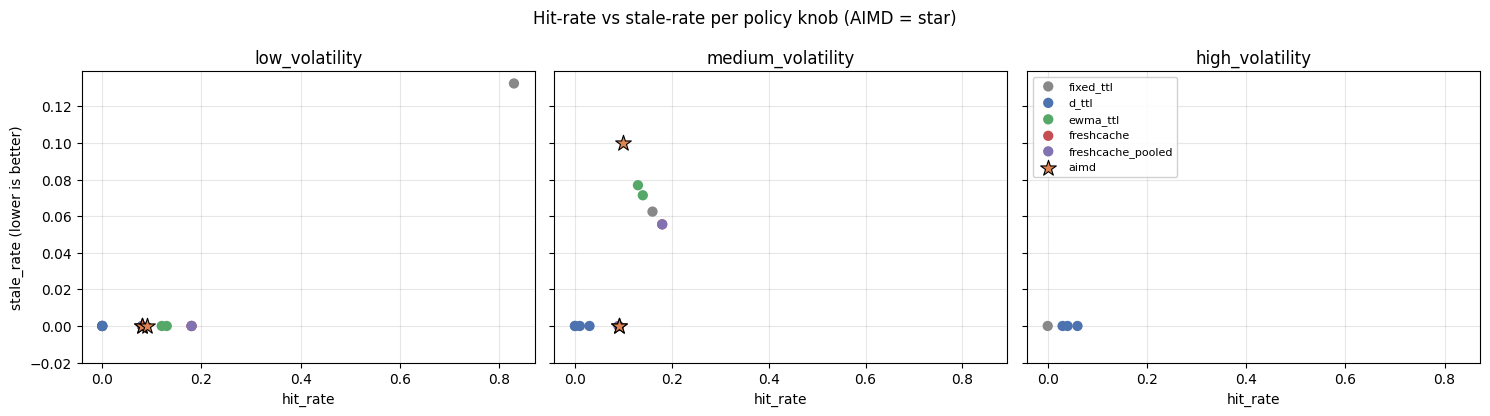

In [16]:
from collections import defaultdict as _dd

print("=" * 78)
print("SCHEMA-DIFF / WIRING-BUG DIAGNOSIS")
print("=" * 78)
print(f"Dataset ever loaded by method.py: {schema_diff['dataset_artifact_ever_loaded_by_method_py']}")

print()
print("=" * 78)
print("MECHANICAL VERDICTS")
print("=" * 78)
print(f"Criterion (a) frontier non-domination:              {verdict_a_synthetic}  (mean non-dominated fraction = {mean_dom:.3f})")
print(f"Criterion (b) low-repeat convergence + FreshCache:   {verdict_b_synthetic}  (AIMD slower in {aimd_slower_count}/{len(REGIMES)} regimes, "
      f"FreshCache calib-failure supported in {freshcache_uncalibrated_support}/{len(REGIMES)} regimes)")

print()
print("=" * 78)
print(f"{'regime':<18}{'family':<20}{'best hit_rate':>14}{'  (95% CI)':>18}{'stale_rate':>13}")
print("=" * 78)
best_by_regime_family = _dd(dict)
for c in bootstrap_cells:
    key = c["regime"]
    fam = c["policy_family"]
    if fam not in best_by_regime_family[key] or (c["hit_rate_point"] or 0) > (best_by_regime_family[key][fam]["hit_rate_point"] or 0):
        best_by_regime_family[key][fam] = c


def _fmt(v, spec=".2f"):
    return format(v, spec) if v is not None else "n/a"


for regime in REGIMES:
    for fam in families_all:
        c = best_by_regime_family[regime].get(fam)
        if c is None:
            continue
        print(f"{regime:<18}{fam:<20}{_fmt(c['hit_rate_point'], '14.3f')}  [{_fmt(c['hit_rate_ci_lo'])},{_fmt(c['hit_rate_ci_hi'])}]{_fmt(c['stale_rate_point'], '13.3f')}")

fig, axes = plt.subplots(1, len(REGIMES), figsize=(5 * len(REGIMES), 4.2), sharey=True)
if len(REGIMES) == 1:
    axes = [axes]
colors = {"fixed_ttl": "#888888", "d_ttl": "#4c72b0", "ewma_ttl": "#55a868", "freshcache": "#c44e52",
          "freshcache_pooled": "#8172b2", "aimd": "#dd8452"}
for ax, regime in zip(axes, REGIMES):
    for family in families_all:
        pts = [(results[(regime, family, k)]["hit_rate"], results[(regime, family, k)]["stale_rate"]) for k in range(len(grid_specs[family]))]
        pts = sorted(pts)
        xs, ys = zip(*pts)
        marker = "*" if family == "aimd" else "o"
        size = 140 if family == "aimd" else 55
        ax.scatter(xs, ys, label=family, color=colors[family], marker=marker, s=size,
                   edgecolor="black" if family == "aimd" else "none", linewidth=0.8, zorder=3 if family == "aimd" else 2)
    ax.set_title(regime)
    ax.set_xlabel("hit_rate")
    ax.set_ylim(bottom=-0.02)
for a in axes:
    a.grid(alpha=0.3)
axes[0].set_ylabel("stale_rate (lower is better)")
axes[-1].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Hit-rate vs stale-rate per policy knob (AIMD = star)")
fig.tight_layout()
plt.show()